<a href="https://colab.research.google.com/github/Charanca24/Data-science-Project/blob/main/Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Detecting Healthcare Provider Fraud Using Aggregated Claims Analysis and Machine Learning**

# **Loading Relevent Files and Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train_target = pd.read_csv('Train.csv')
train_ben = pd.read_csv('Train_Beneficiarydata.csv')
train_inpatient = pd.read_csv('Train_Inpatientdata.csv')
train_outpatient = pd.read_csv('Train_Outpatientdata.csv', engine='python')

# Combine Inpatient and Outpatient for a holistic view of claims
train_inpatient['Type'] = 'Inpatient'
train_outpatient['Type'] = 'Outpatient'
all_claims = pd.concat([train_inpatient, train_outpatient], axis=0, sort=False)

# Merge claims with the fraud labels
full_data = pd.merge(all_claims, train_target, on='Provider', how='left')

#**Exploratory Data Analysis**

## **Dataset Description**


In [ ]:
full_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,Type,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No


In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558211 entries, 0 to 558210
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  558211 non-null  object 
 1   ClaimID                 558211 non-null  object 
 2   ClaimStartDt            558211 non-null  object 
 3   ClaimEndDt              558211 non-null  object 
 4   Provider                558211 non-null  object 
 5   InscClaimAmtReimbursed  558211 non-null  int64  
 6   AttendingPhysician      556703 non-null  object 
 7   OperatingPhysician      114447 non-null  object 
 8   OtherPhysician          199736 non-null  object 
 9   AdmissionDt             40474 non-null   object 
 10  ClmAdmitDiagnosisCode   145899 non-null  object 
 11  DeductibleAmtPaid       557312 non-null  float64
 12  DischargeDt             40474 non-null   object 
 13  DiagnosisGroupCode      40474 non-null   object 
 14  ClmDiagnosisCode_1  

## **Checking and Handling Missing Values**
In this missing values are identified and handeled with imputation

--- Missing Values in Target Labels ---


,Total,Percentage




--- Missing Values in Beneficiary Data ---


,Total,Percentage
DOD,137135,98.974422




--- Missing Values in Inpatient Claims ---


,Total,Percentage
ClmProcedureCode_6,40474,100.000000
ClmProcedureCode_5,40465,99.977764
ClmProcedureCode_4,40358,99.713396
ClmProcedureCode_3,39509,97.615753
ClmDiagnosisCode_10,36547,90.297475
OtherPhysician,35784,88.412314
ClmProcedureCode_2,35020,86.524683
ClmProcedureCode_1,17326,42.807728
OperatingPhysician,16644,41.122696
ClmDiagnosisCode_9,13497,33.347334




--- Missing Values in Outpatient Claims ---


,Total,Percentage
ClmProcedureCode_6,517737,100.000000
ClmProcedureCode_5,517737,100.000000
ClmProcedureCode_4,517735,99.999614
ClmProcedureCode_3,517733,99.999227
ClmProcedureCode_2,517701,99.993047
ClmProcedureCode_1,517575,99.968710
ClmDiagnosisCode_10,516654,99.790820
ClmDiagnosisCode_9,502899,97.134066
ClmDiagnosisCode_8,494825,95.574587
ClmDiagnosisCode_7,484776,93.633640


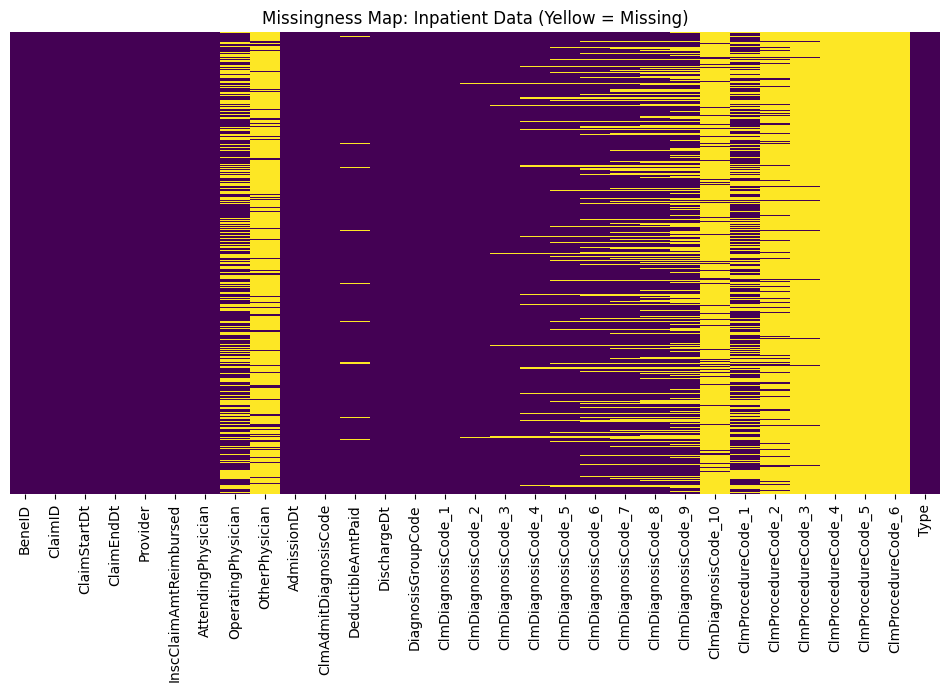

In [ ]:
def missing_data_check(df, name):
    print(f"--- Missing Values in {name} ---")
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percentage'])
    # Only show columns that actually have missing values
    display(missing_df[missing_df['Total'] > 0].sort_values(by='Total', ascending=False))
    print("\n")

# 1. Check for missing values in each file
missing_data_check(train_target, "Target Labels")
missing_data_check(train_ben, "Beneficiary Data")
missing_data_check(train_inpatient, "Inpatient Claims")
missing_data_check(train_outpatient, "Outpatient Claims")

# 2. Visualizing Missing Data Patterns (Inpatient example)
# This helps identify if certain columns (like Procedure Codes) are missing together
plt.figure(figsize=(12, 6))
sns.heatmap(train_inpatient.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missingness Map: Inpatient Data (Yellow = Missing)')
plt.show()

In [ ]:
# 1. Handling Beneficiary Data (Demographics & Chronic Conditions)
# DOD (Date of Death) is naturally empty for living patients.
# We create a binary 'IsDeceased' flag and then drop/ignore the date for modeling.
train_ben['IsDeceased'] = train_ben['DOD'].notnull().astype(int)

# 2. Handling Financial Nulls
# Financial columns should never be null. Fill with 0 to ensure aggregations work.
financial_cols = ['InscClaimAmtReimbursed', 'DeductibleAmtPaid']
train_inpatient[financial_cols] = train_inpatient[financial_cols].fillna(0)
train_outpatient[financial_cols] = train_outpatient[financial_cols].fillna(0)

# 3. Handling Categorical Sparse Data (Diagnosis & Procedure Codes)
# In this dataset, 'NA' in DiagnosisCode_10 just means the patient didn't have 10 conditions.
# We fill these with a specific 'None' string so they can be encoded later.
diag_cols = [col for col in train_inpatient.columns if 'ClmDiagnosisCode' in col]
proc_cols = [col for col in train_inpatient.columns if 'ClmProcedureCode' in col]

train_inpatient[diag_cols] = train_inpatient[diag_cols].fillna('None')
train_inpatient[proc_cols] = train_inpatient[proc_cols].fillna('None')
train_outpatient[diag_cols] = train_outpatient[diag_cols].fillna('None')
train_outpatient[proc_cols] = train_outpatient[proc_cols].fillna('None')

# 4. Handling Physician Nulls
# If a physician is missing, we label it as 'Unknown' to maintain the count
# but differentiate it from known providers.
physician_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']
for col in physician_cols:
    train_inpatient[col] = train_inpatient[col].fillna('Unknown')
    train_outpatient[col] = train_outpatient[col].fillna('Unknown')

# 5. Handling Admitting Diagnosis
# This is often missing in Outpatient data as those visits are less formal than admissions.
train_inpatient['ClmAdmitDiagnosisCode'] = train_inpatient['ClmAdmitDiagnosisCode'].fillna('None')
train_outpatient['ClmAdmitDiagnosisCode'] = train_outpatient['ClmAdmitDiagnosisCode'].fillna('None')

print("Missing values successfully handled.")

Missing values successfully handled.


In [ ]:
print(train_inpatient.isnull().sum().sum()) # Should be 0 for critical columns

0


## **Target Variable Distribution**
Understanding the imbalance is the first step in fraud detection. Fraudulent providers are usually a small fraction of the total.

/tmp/ipykernel_3068/3393778264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='PotentialFraud', data=train_target, palette='magma')


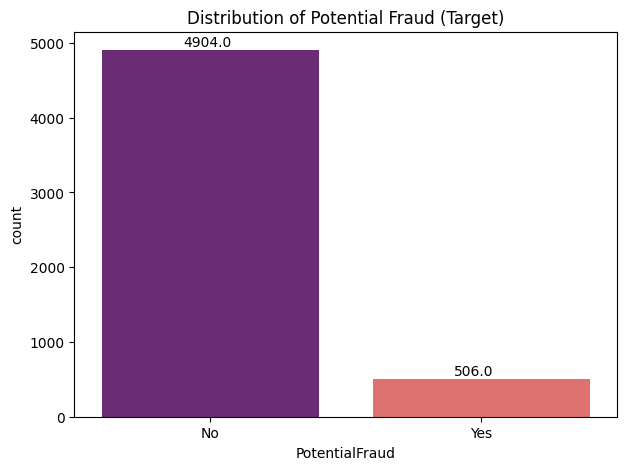

Percentage Distribution:
PotentialFraud
No     90.64695
Yes     9.35305
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='PotentialFraud', data=train_target, palette='magma')
plt.title('Distribution of Potential Fraud (Target)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+50))
plt.show()

print("Percentage Distribution:")
print(train_target['PotentialFraud'].value_counts(normalize=True) * 100)

## **Correlation Metrics**
We examine how strongly the aggregated features correlate with the FraudLabel.

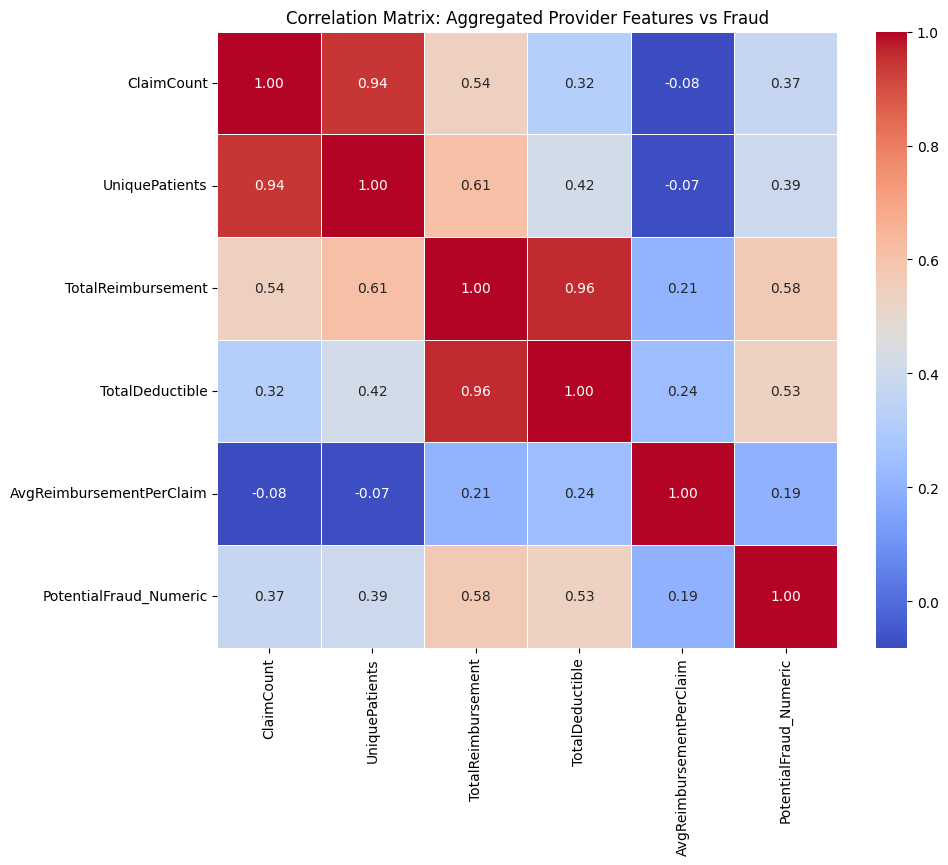

In [ ]:
# Aggregate full_data by Provider to create df_eda
# This step calculates various metrics per provider that can be used as features.
df_agg = full_data.groupby('Provider').agg(
    ClaimCount=('ClaimID', 'nunique'), # Number of unique claims per provider
    UniquePatients=('BeneID', 'nunique'), # Number of unique patients per provider
    TotalReimbursement=('InscClaimAmtReimbursed', 'sum'), # Total reimbursement amount
    TotalDeductible=('DeductibleAmtPaid', 'sum'), # Total deductible paid
    AvgReimbursementPerClaim=('InscClaimAmtReimbursed', 'mean') # Average reimbursement per claim
).reset_index()

# Merge aggregated data with the target labels (PotentialFraud)
df_eda = pd.merge(df_agg, train_target, on='Provider', how='left')

# Convert 'PotentialFraud' to numerical for correlation calculation
df_eda['PotentialFraud_Numeric'] = df_eda['PotentialFraud'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 8))
# Calculating Pearson Correlation
corr_matrix = df_eda.drop(columns=['Provider', 'PotentialFraud']).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Aggregated Provider Features vs Fraud')
plt.show()

## **Financial Outlier Analysis (Violin Plots)**
Fraudulent providers often exhibit different distribution shapes in their billing amounts.

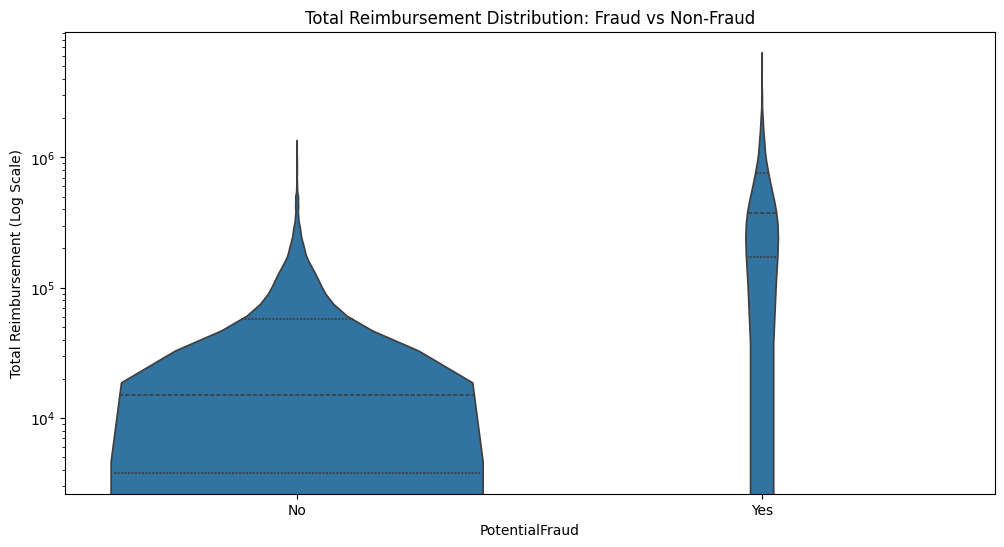

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='PotentialFraud', y='TotalReimbursement', data=df_eda, inner="quartile")
plt.yscale('log') # Log scale helps visualize the wide range of billing
plt.title('Total Reimbursement Distribution: Fraud vs Non-Fraud')
plt.ylabel('Total Reimbursement (Log Scale)')
plt.show()

## **Claim Volume vs. Patient Count**
One common fraud indicator is a provider having an unusually high number of claims per patient.

/tmp/ipykernel_3068/960217456.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_eda[df_eda['PotentialFraud']=='No']['ClaimsPerPatient'], label='Not Fraud', shade=True)
/tmp/ipykernel_3068/960217456.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_eda[df_eda['PotentialFraud']=='Yes']['ClaimsPerPatient'], label='Fraud', shade=True)


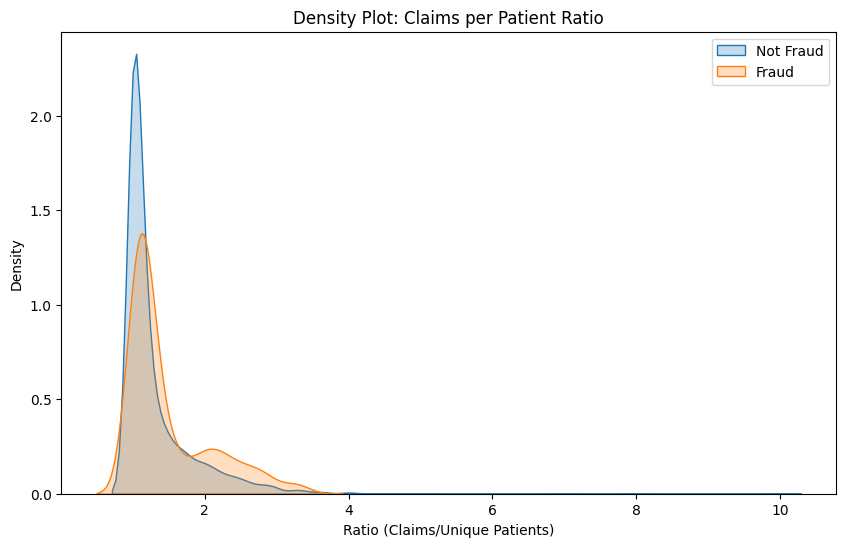

In [ ]:
df_eda['ClaimsPerPatient'] = df_eda['ClaimCount'] / df_eda['UniquePatients']

plt.figure(figsize=(10, 6))
sns.kdeplot(df_eda[df_eda['PotentialFraud']=='No']['ClaimsPerPatient'], label='Not Fraud', shade=True)
sns.kdeplot(df_eda[df_eda['PotentialFraud']=='Yes']['ClaimsPerPatient'], label='Fraud', shade=True)
plt.title('Density Plot: Claims per Patient Ratio')
plt.xlabel('Ratio (Claims/Unique Patients)')
plt.legend()
plt.show()

In [ ]:
full_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,Type,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inpatient,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,Inpatient,No


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Work on a copy so upstream EDA cells are unaffected
model_data = full_data.copy()

# 1. Date conversion + useful date features
date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt']
for col in date_cols:
    if col in model_data.columns:
        model_data[col] = pd.to_datetime(model_data[col], errors='coerce')

model_data['ClaimDuration'] = (model_data['ClaimEndDt'] - model_data['ClaimStartDt']).dt.days
model_data['HospStayDuration'] = (model_data['DischargeDt'] - model_data['AdmissionDt']).dt.days
model_data['ClaimDuration'] = model_data['ClaimDuration'].clip(lower=0)
model_data['HospStayDuration'] = model_data['HospStayDuration'].clip(lower=0)

model_data['ClaimStartMonth'] = model_data['ClaimStartDt'].dt.month
model_data['ClaimStartDayOfWeek'] = model_data['ClaimStartDt'].dt.dayofweek
model_data['ClaimStartIsWeekend'] = model_data['ClaimStartDayOfWeek'].isin([5, 6]).astype(int)

# 2. Sparse code count features
diag_cols = [col for col in model_data.columns if 'Diagnosis' in col]
proc_cols = [col for col in model_data.columns if 'Procedure' in col]
model_data['TotalDiag'] = model_data[diag_cols].notnull().sum(axis=1)
model_data['TotalProc'] = model_data[proc_cols].notnull().sum(axis=1)

# 3. Encode target and inpatient flag
model_data['PotentialFraud'] = model_data['PotentialFraud'].map({'Yes': 1, 'No': 0})
model_data['IsInpatient'] = (model_data['Type'] == 'Inpatient').astype(int)

# 4. Frequency-encode high-cardinality IDs instead of dropping all signal
for id_col in ['Provider', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'BeneID']:
    if id_col in model_data.columns:
        counts = model_data[id_col].fillna('UNK').value_counts()
        model_data[f'{id_col}_freq'] = model_data[id_col].fillna('UNK').map(counts).astype(float)

# Physician coverage features
for col in ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']:
    if col in model_data.columns:
        model_data[f'{col}_missing'] = model_data[col].isna().astype(int)

# Financial intensity features
if {'InscClaimAmtReimbursed', 'DeductibleAmtPaid'}.issubset(model_data.columns):
    model_data['TotalPaid'] = model_data['InscClaimAmtReimbursed'].fillna(0) + model_data['DeductibleAmtPaid'].fillna(0)
    model_data['DeductibleToReimbRatio'] = model_data['DeductibleAmtPaid'].fillna(0) / (model_data['InscClaimAmtReimbursed'].fillna(0) + 1)
    model_data['ReimbPerClaimDay'] = model_data['InscClaimAmtReimbursed'].fillna(0) / (model_data['ClaimDuration'].fillna(0) + 1)

# 5. Drop raw string/date columns after engineered features are created
cols_to_drop = date_cols + diag_cols + proc_cols + ['ClaimID', 'Type']
remaining_objs = model_data.drop(columns=['PotentialFraud'], errors='ignore').select_dtypes(include=['object']).columns.tolist()
final_drop = list(set(cols_to_drop + remaining_objs))

df_model = model_data.drop(columns=final_drop, errors='ignore')

# Keep only numeric columns and fill missing values
feature_cols = [c for c in df_model.columns if c != 'PotentialFraud']
df_model[feature_cols] = df_model[feature_cols].apply(pd.to_numeric, errors='coerce')
df_model[feature_cols] = df_model[feature_cols].fillna(df_model[feature_cols].median())
df_model['PotentialFraud'] = df_model['PotentialFraud'].fillna(0).astype(int)

print(f"Cleaned data shape: {df_model.shape}")
print(df_model.dtypes.value_counts())
print(f"Fraud rate: {df_model['PotentialFraud'].mean():.4f}")

Cleaned data shape: (558211, 22)
int64      10
float64    10
int32       2
Name: count, dtype: int64
Fraud rate: 0.3812


In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train/test split
X = df_model.drop('PotentialFraud', axis=1)
y = df_model['PotentialFraud']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Class imbalance ratio for boosting models
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- 1. XGBoost ---
xgb_clf = xgb.XGBClassifier(
    n_estimators=450,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    reg_lambda=2.0,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=42
)
xgb_clf.fit(X_train, y_train)

# --- 2. LightGBM ---
lgb_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=60,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight='balanced',
    importance_type='gain',
    random_state=42,
    verbose=-1
)
lgb_clf.fit(X_train, y_train)

# --- 3. Random Forest ---
rf_clf = RandomForestClassifier(
    n_estimators=350,
    max_depth=22,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train, y_train)

print("All three models have been trained successfully with richer features and stronger hyperparameters.")

All three models have been trained successfully with richer features and stronger hyperparameters.


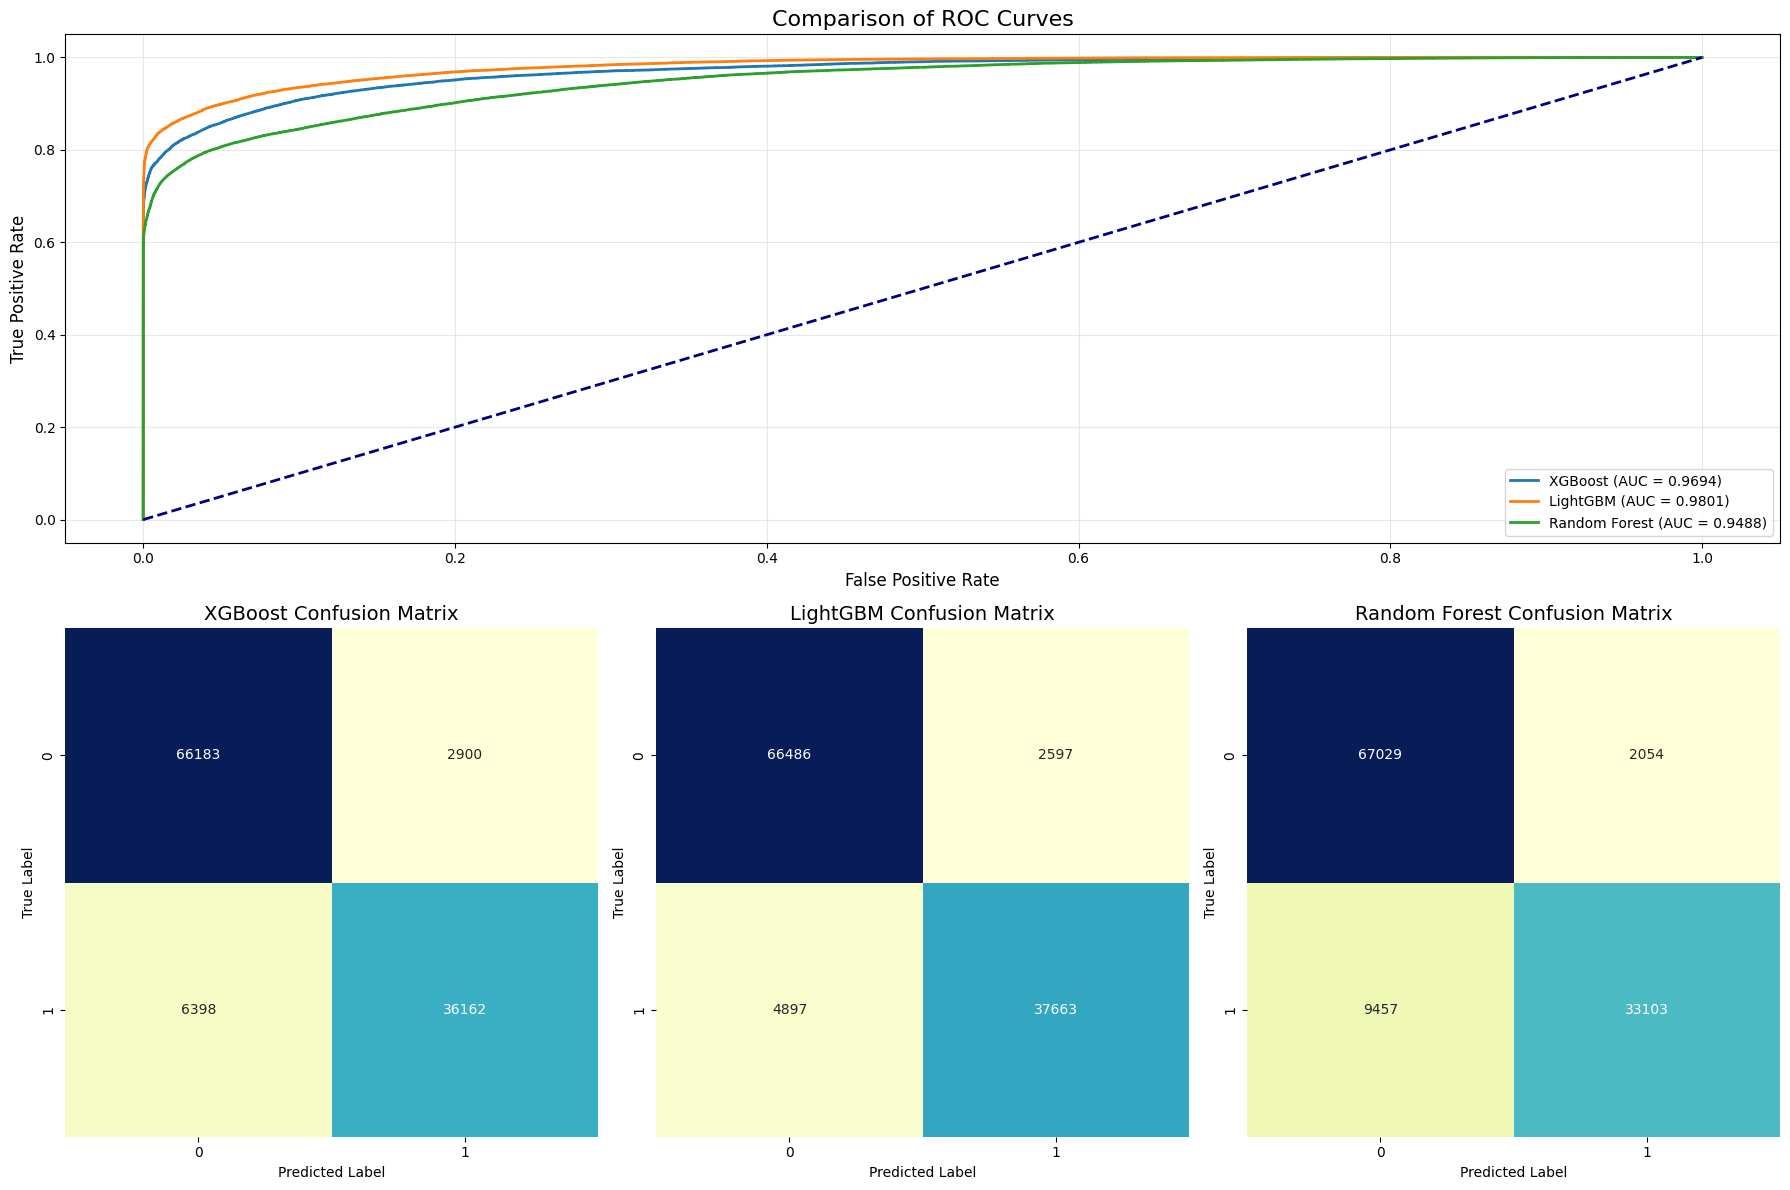

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

def plot_all_performances(models, X_test, y_test):
    num_models = len(models)
    # Set up a grid: Top row for ROC, bottom row(s) for Confusion Matrices
    fig = plt.figure(figsize=(18, 12))

    # --- 1. Combined ROC Curve (Spanning the top) ---
    ax_roc = plt.subplot2grid((2, num_models), (0, 0), colspan=num_models)
    for name, model in models.items():
        probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_title('Comparison of ROC Curves', fontsize=16)
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.legend(loc='lower right')
    ax_roc.grid(alpha=0.3)

    # --- 2. Individual Confusion Matrices (Bottom Row) ---
    for i, (name, model) in enumerate(models.items()):
        ax_cm = plt.subplot2grid((2, num_models), (1, i))
        preds = model.predict(X_test)
        cm = confusion_matrix(y_test, preds)

        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax_cm, cbar=False)
        ax_cm.set_title(f'{name} Confusion Matrix', fontsize=14)
        ax_cm.set_xlabel('Predicted Label')
        ax_cm.set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

# Execute the updated visualization
models_dict = {'XGBoost': xgb_clf, 'LightGBM': lgb_clf, 'Random Forest': rf_clf}
plot_all_performances(models_dict, X_test, y_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

results = []

for name, model in models_dict.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    res = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, probs)
    }
    results.append(res)

# Create a Summary Table
perf_df = pd.DataFrame(results).set_index('Model')
print("--- Summarized Evaluation Metrics ---")
print(perf_df.round(4))

# Print Detailed Classification Reports
for name, model in models_dict.items():
    print(f"\nDetailed Classification Report for {name}:")
    print(classification_report(y_test, model.predict(X_test)))

--- Summarized Evaluation Metrics ---
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
XGBoost          0.9167     0.9258  0.8497    0.8861   0.9694
LightGBM         0.9329     0.9355  0.8849    0.9095   0.9801
Random Forest    0.8969     0.9416  0.7778    0.8519   0.9488

Detailed Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     69083
           1       0.93      0.85      0.89     42560

    accuracy                           0.92    111643
   macro avg       0.92      0.90      0.91    111643
weighted avg       0.92      0.92      0.92    111643


Detailed Classification Report for LightGBM:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     69083
           1       0.94      0.88      0.91     42560

    accuracy                           0.93    111643
   macro avg    

Starting Hyperparameter Optimization (Targeting Recall)...
 Best parameters for XGBoost: {'scale_pos_weight': np.float64(2.434843393876736), 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


 Best parameters for LightGBM: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.05, 'is_unbalance': True}
 Best parameters for RandomForest: {'n_estimators': 100, 'max_depth': None, 'class_weight': 'balanced_subsample'}

FINAL EVALUATION OF OPTIMIZED MODELS
              Accuracy  Precision  Recall (Catch Rate)  F1-Score  AUC-ROC
Model                                                                    
XGBoost         0.9052     0.8623               0.8940    0.8779   0.9680
LightGBM        0.9153     0.9243               0.8472    0.8841   0.9681
RandomForest    0.9082     0.9667               0.7862    0.8671   0.9613


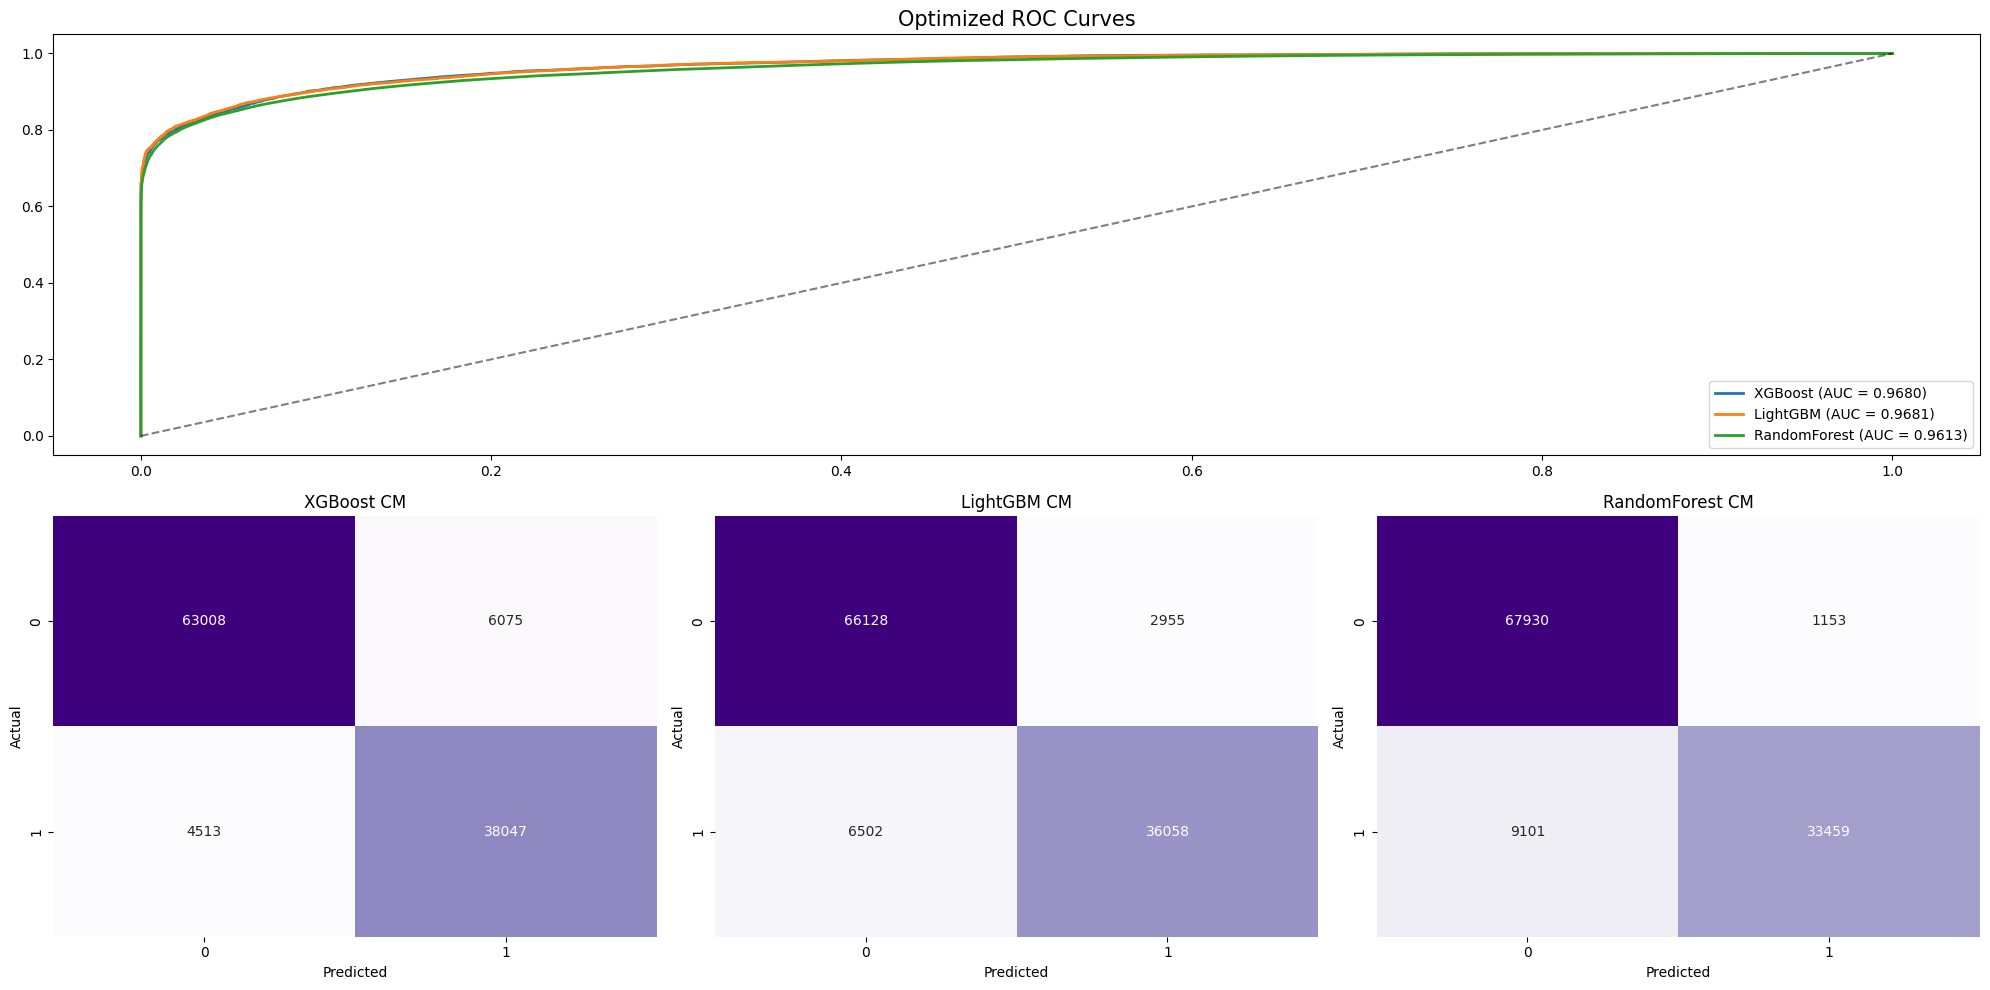

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

# 1. Setup Search Parameters
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

search_configs = {
    'XGBoost': {
        'model': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'scale_pos_weight': [ratio, ratio * 1.5]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'num_leaves': [31, 64],
            'learning_rate': [0.01, 0.05, 0.1],
            'is_unbalance': [True]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'class_weight': ['balanced', 'balanced_subsample']
        }
    }
}

optimized_models = {}

# 2. Run Optimization and Print Best Params
print("Starting Hyperparameter Optimization (Targeting Recall)...")
for name, config in search_configs.items():
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=5, # Number of iterations per model
        scoring='recall',
        cv=3,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    search.fit(X_train, y_train)
    optimized_models[name] = search.best_estimator_
    print(f" Best parameters for {name}: {search.best_params_}")

# 3. Final Evaluation Summary
summary_data = []
for name, model in optimized_models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    summary_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall (Catch Rate)': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, probs)
    })

print("\n" + "="*50)
print("FINAL EVALUATION OF OPTIMIZED MODELS")
print("="*50)
print(pd.DataFrame(summary_data).set_index('Model').round(4))

# 4. Visualization: ROC and Confusion Matrices
fig = plt.figure(figsize=(20, 10))

# ROC Curve
ax_roc = plt.subplot2grid((2, 3), (0, 0), colspan=3)
for name, model in optimized_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.4f})', lw=2)

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_roc.set_title('Optimized ROC Curves', fontsize=15)
ax_roc.legend()

# Confusion Matrices
for i, (name, model) in enumerate(optimized_models.items()):
    ax_cm = plt.subplot2grid((2, 3), (1, i))
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax_cm, cbar=False)
    ax_cm.set_title(f'{name} CM')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Split train further so threshold selection is done on validation (not test)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

smote = SMOTE(sampling_strategy=0.8, random_state=42)

smote_configs = {
    'XGBoost': {
        'model': xgb.XGBClassifier(eval_metric='aucpr', random_state=42, tree_method='hist'),
        'params': {
            'classifier__n_estimators': [250, 400],
            'classifier__max_depth': [4, 6, 8],
            'classifier__learning_rate': [0.03, 0.05, 0.08],
            'classifier__subsample': [0.85, 1.0],
            'classifier__colsample_bytree': [0.85, 1.0]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            'classifier__n_estimators': [250, 400],
            'classifier__num_leaves': [31, 63, 95],
            'classifier__learning_rate': [0.03, 0.05, 0.08],
            'classifier__min_child_samples': [30, 60]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'classifier__n_estimators': [250, 400],
            'classifier__max_depth': [14, 22, None],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    }
}

smote_results = {}
thresholds = {}

print("Starting SMOTE + threshold optimization for better F1 and recall...")

for name, config in smote_configs.items():
    pipeline = ImbPipeline([
        ('smote', smote),
        ('classifier', config['model'])
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['params'],
        n_iter=4,
        scoring='f1',
        cv=2,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    search.fit(X_fit, y_fit)
    best_model = search.best_estimator_

    # Tune decision threshold on validation to lift recall while preserving F1
    val_probs = best_model.predict_proba(X_val)[:, 1]
    candidate_thresholds = np.linspace(0.15, 0.85, 71)

    best_t, best_score = 0.5, -1
    for t in candidate_thresholds:
        val_pred = (val_probs >= t).astype(int)
        rec = recall_score(y_val, val_pred, zero_division=0)
        f1 = f1_score(y_val, val_pred, zero_division=0)
        # Weighted objective favors F1 while still pushing recall up
        score = 0.65 * f1 + 0.35 * rec
        if score > best_score:
            best_score = score
            best_t = t

    smote_results[name] = best_model
    thresholds[name] = best_t
    print(f"{name}: best params found, threshold={best_t:.2f}")

# Final test-set evaluation
final_metrics = []
for name, model in smote_results.items():
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= thresholds[name]).astype(int)

    final_metrics.append({
        'Model': name,
        'Threshold': thresholds[name],
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, probs)
    })

smote_perf_df = pd.DataFrame(final_metrics).set_index('Model').sort_values(
    by=['F1-Score', 'Recall'], ascending=False
)
print("\n--- FINAL PERFORMANCE WITH SMOTE + THRESHOLD TUNING ---")
print(smote_perf_df.round(4))

best_f1_model_name = smote_perf_df.index[0]
best_recall_model_name = smote_perf_df.sort_values(by='Recall', ascending=False).index[0]
print(f"\nBest by F1: {best_f1_model_name}")
print(f"Best by Recall: {best_recall_model_name}")

Starting SMOTE + threshold optimization for better F1 and recall...
XGBoost: best params found, threshold=0.34
LightGBM: best params found, threshold=0.31
RandomForest: best params found, threshold=0.36

--- FINAL PERFORMANCE WITH SMOTE + THRESHOLD TUNING ---
              Threshold  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                  
LightGBM           0.31    0.9297     0.8929  0.9266    0.9094   0.9836
XGBoost            0.34    0.9055     0.8654  0.8906    0.8778   0.9677
RandomForest       0.36    0.8716     0.8214  0.8475    0.8342   0.9444

Best by F1: LightGBM
Best by Recall: LightGBM


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Threshold-aware CV for SMOTE-tuned models
# This evaluates the objective we actually care about: recall + F1.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use tuned models from the previous SMOTE+search cell as templates
cv_models = {
    'XGBoost': smote_results['XGBoost'],
    'LightGBM': smote_results['LightGBM'],
    'RandomForest': smote_results['RandomForest']
}

cv_summary = {}
print("Starting threshold-aware 5-fold CV on SMOTE-tuned models...")

for name, model_template in cv_models.items():
    fold_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'roc_auc': [],
        'threshold': []
    }

    for fold_id, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_test_fold = X.iloc[test_idx]
        y_test_fold = y.iloc[test_idx]

        # Inner split: train model on fit set, tune threshold on tune set
        X_fit_fold, X_tune_fold, y_fit_fold, y_tune_fold = train_test_split(
            X_train_fold, y_train_fold, test_size=0.2, stratify=y_train_fold, random_state=42
        )

        model = clone(model_template)
        model.fit(X_fit_fold, y_fit_fold)

        tune_probs = model.predict_proba(X_tune_fold)[:, 1]
        candidate_thresholds = np.linspace(0.15, 0.85, 71)

        best_t, best_score = 0.5, -1
        for t in candidate_thresholds:
            tune_pred = (tune_probs >= t).astype(int)
            rec = recall_score(y_tune_fold, tune_pred, zero_division=0)
            f1 = f1_score(y_tune_fold, tune_pred, zero_division=0)
            score = 0.65 * f1 + 0.35 * rec
            if score > best_score:
                best_score = score
                best_t = t

        test_probs = model.predict_proba(X_test_fold)[:, 1]
        test_pred = (test_probs >= best_t).astype(int)

        fold_scores['accuracy'].append(accuracy_score(y_test_fold, test_pred))
        fold_scores['precision'].append(precision_score(y_test_fold, test_pred, zero_division=0))
        fold_scores['recall'].append(recall_score(y_test_fold, test_pred, zero_division=0))
        fold_scores['f1'].append(f1_score(y_test_fold, test_pred, zero_division=0))
        fold_scores['roc_auc'].append(roc_auc_score(y_test_fold, test_probs))
        fold_scores['threshold'].append(best_t)

    cv_summary[name] = {
        'Avg Accuracy': np.mean(fold_scores['accuracy']),
        'Avg Precision': np.mean(fold_scores['precision']),
        'Avg Recall': np.mean(fold_scores['recall']),
        'Avg F1-Score': np.mean(fold_scores['f1']),
        'Avg AUC-ROC': np.mean(fold_scores['roc_auc']),
        'Avg Threshold': np.mean(fold_scores['threshold']),
        'F1 StdDev': np.std(fold_scores['f1'])
    }
    print(f"{name}: threshold-aware CV complete.")

results_df = pd.DataFrame(cv_summary).T.sort_values(by=['Avg F1-Score', 'Avg Recall'], ascending=False)
print("\n--- THRESHOLD-AWARE STRATIFIED CV SUMMARY (SMOTE-TUNED MODELS) ---")
print(results_df.round(4))

Starting threshold-aware 5-fold CV on SMOTE-tuned models...
XGBoost: threshold-aware CV complete.
LightGBM: threshold-aware CV complete.
RandomForest: threshold-aware CV complete.

--- THRESHOLD-AWARE STRATIFIED CV SUMMARY (SMOTE-TUNED MODELS) ---
              Avg Accuracy  Avg Precision  Avg Recall  Avg F1-Score  \
LightGBM            0.9282         0.8878      0.9290        0.9079   
XGBoost             0.8954         0.8368      0.9021        0.8681   
RandomForest        0.8607         0.7914      0.8639        0.8256   

              Avg AUC-ROC  Avg Threshold  F1 StdDev  
LightGBM           0.9833          0.296     0.0009  
XGBoost            0.9657          0.308     0.0068  
RandomForest       0.9439          0.338     0.0082  


/tmp/ipykernel_3068/1692682361.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


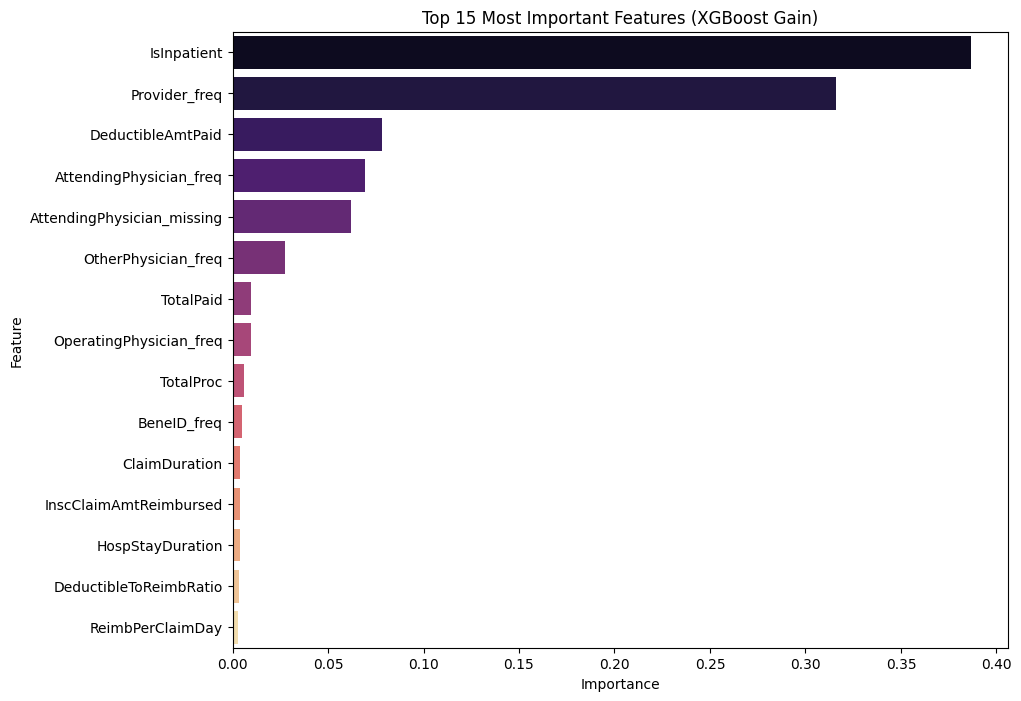

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use XGBoost as the example, but you can swap in lgb_clf
# Sorting features by importance
importances = xgb_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 15 Most Important Features (XGBoost Gain)')
plt.show()